In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import os
import kagglehub  # pip install kagglehub

## Load Data

In [ ]:
def combine_insta_cart_datasets():

    # Base path for Instacart data
    base_path = '/Users/es864k/.cache/kagglehub/datasets/psparks/instacart-market-basket-analysis/versions/1'

    # Read all source files
    print("Loading datasets...")
    aisles = pd.read_csv(os.path.join(base_path, 'aisles.csv'))
    departments = pd.read_csv(os.path.join(base_path, 'departments.csv'))
    products = pd.read_csv(os.path.join(base_path, 'products.csv'))
    orders = pd.read_csv(os.path.join(base_path, 'orders.csv'))
    order_products_prior = pd.read_csv(os.path.join(base_path, 'order_products__prior.csv'))
    order_products_train = pd.read_csv(os.path.join(base_path, 'order_products__train.csv'))
                                   

    # Combine prior and train order products
    print("Combining order products (prior + train)...")
    order_products = pd.concat([order_products_prior, order_products_train], ignore_index=True)

    # Merge products with aisles and departments
    print("Enriching products with aisle and department names...")
    products_enriched = products.merge(aisles, on='aisle_id', how='left')
    products_enriched = products_enriched.merge(departments, on='department_id', how='left')

    # Merge order_products with enriched products
    print("Joining order products with product details...")
    order_products_enriched = order_products.merge(products_enriched, on='product_id', how='left')

    # Merge with orders to get order-level info
    print("Adding order metadata (user, day, hour, etc.)...")
    combined = order_products_enriched.merge(orders, on='order_id', how='left')

    # Reorder columns for clarity
    column_order = [
        'order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
        'days_since_prior_order', 'eval_set',
        'product_id', 'product_name', 'aisle_id', 'aisle', 'department_id', 'department',
        'add_to_cart_order', 'reordered'
    ]
    combined = combined[column_order]

    # Save combined dataset
    output_file = 'instacart_combined.csv'
    print(f"Saving combined dataset to {output_file}...")
    combined.to_csv(output_file, index=False)

    print(f"\nDone! Combined dataset has {len(combined):,} rows and {len(combined.columns)} columns.")
    print(f"Columns: {list(combined.columns)}")

In [4]:
SAMPLE_SIZE = 50000 # some of the data sets are large 


def load_csv_sampled(filepath, sample_size=SAMPLE_SIZE, random_state=42, sep=None, encoding=None, **kwargs):
    # try encodings in order
    encodings = [encoding] if encoding else ['utf-8', 'latin-1', 'cp1252']
    
    for enc in encodings:
        try:
            # auto-detect delimiter
            if sep is None:
                with open(filepath, 'r', encoding=enc) as f:
                    first_line = f.readline()
                    sep = '\t' if '\t' in first_line else ','
            
            row_count = sum(1 for _ in open(filepath, encoding=enc)) - 1
            
            if sample_size and row_count > sample_size:
                np.random.seed(random_state)
                skip_idx = np.random.choice(range(1, row_count + 1), size=int(row_count * (1 - sample_size/row_count)), replace=False)
                df = pd.read_csv(filepath, skiprows=skip_idx, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows (sampled from {row_count:,}) [encoding: {enc}]")
            else:
                df = pd.read_csv(filepath, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows [encoding: {enc}]")
            return df
        except UnicodeDecodeError:
            continue
    
    raise ValueError(f"Could not decode file with encodings: {encodings}")

In [5]:
# Load Data using default sample 
# instacart is 3Million records so we are just going to use about 50K
df = load_csv_sampled("../data_us_ecommerce_records.csv")

Loaded 3,312 rows [encoding: latin-1]


## Preprocessing

In [6]:
def summarize_df(df):
    print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
    df.info()
    print("")
    print("Numeric")
    display(df.describe().T)
    cat_cols = df.select_dtypes(include=['object', 'category'])
    if cat_cols.shape[1] > 0:
        print("Categorical")
        display(cat_cols.describe().T)


pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


print("summarize sample")
summarize_df(df)

summarize sample
Shape: 3,312 x 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float6

,count,mean,std,min,25%,50%,75%,max
Row ID,3312.0,5087.107488,2817.482266,13.0000,2655.7500,5183.5000,7498.250000,9994.0000
Postal Code,3312.0,56186.515097,31980.375516,1841.0000,27978.7500,60472.5000,90032.000000,99301.0000
Sales,3312.0,221.381418,585.257531,0.4440,17.0180,53.8100,205.105700,13999.9600
Quantity,3312.0,3.766908,2.221776,1.0000,2.0000,3.0000,5.000000,14.0000
Discount,3312.0,0.156467,0.207429,0.0000,0.0000,0.2000,0.200000,0.8000
Profit,3312.0,28.212340,241.864342,-3839.9904,1.7632,8.2968,28.315125,6719.9808


Categorical


,count,unique,top,freq
Order Date,3312,322,02-09-20,36
Order ID,3312,1687,CA-2017-100111,14
Ship Mode,3312,4,Standard Class,1897
Customer ID,3312,693,SV-20365,20
Segment,3312,3,Consumer,1668
Country,3312,1,United States,3312
City,3312,350,New York City,306
State,3312,47,California,663
Region,3312,4,West,1095
Product ID,3312,1525,FUR-CH-10003774,8


In [7]:
def check_dup_rows(df):
    dups = df.duplicated().sum()
    print(f"Duplicate rows: {dups:,} ({dups/len(df)*100:.2f}%)")
    if dups > 0:
        display(df[df.duplicated(keep=False)].head(10))
    return dups



print("duplicate row checks")
check_dup_rows(df)

print("\n")


duplicate row checks
Duplicate rows: 0 (0.00%)




duplicate column checks 


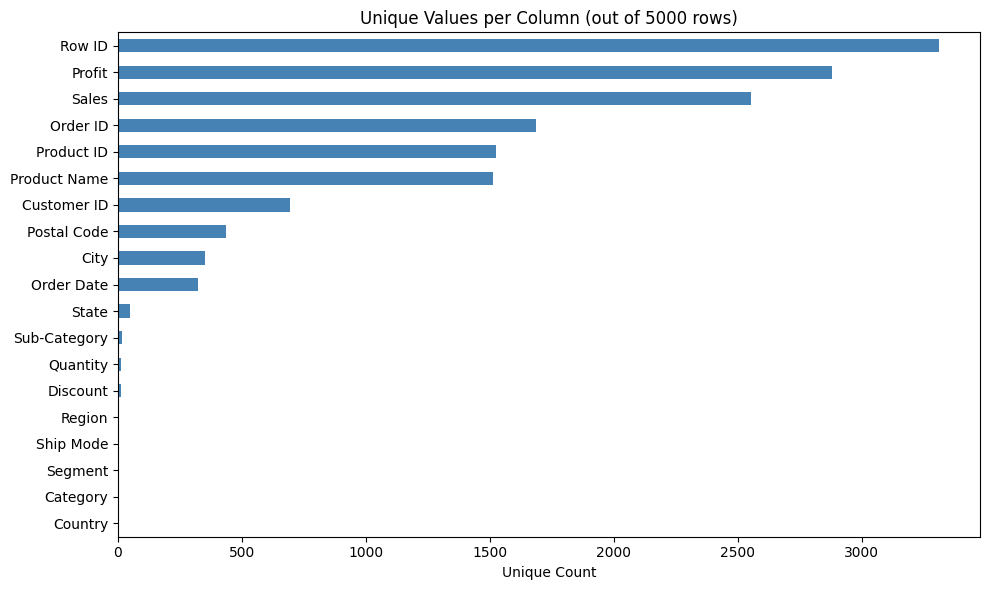

              Unique Count  Total Row Count
Country                  1             3312
Category                 3             3312
Segment                  3             3312
Ship Mode                4             3312
Region                   4             3312
Discount                12             3312
Quantity                14             3312
Sub-Category            17             3312
State                   47             3312
Order Date             322             3312
City                   350             3312
Postal Code            437             3312
Customer ID            693             3312
Product Name          1511             3312
Product ID            1525             3312
Order ID              1687             3312
Sales                 2552             3312
Profit                2881             3312
Row ID                3312             3312


In [8]:
import matplotlib.pyplot as plt
def check_dup_values(df):
    unique_counts = df.nunique()
    # Get the total row count
    total_rows = df.shape[0]

    # Create a new DataFrame with the results
    summary_df = pd.DataFrame({
        'Unique Count': unique_counts,
        'Total Row Count': total_rows
    })

    # Display the summary DataFrame
    summary_df.sort_values('Unique Count', inplace=True)
    summary_df['Unique Count'].plot(kind='barh', figsize=(10, 6), color='steelblue')
    plt.xlabel('Unique Count')
    plt.title('Unique Values per Column (out of 5000 rows)')
    plt.tight_layout()
    plt.show()
    print(summary_df)

print("duplicate column checks ")
check_dup_values(df)


## Univariate Analysis

In [9]:
## helpers
import matplotlib.pyplot as plt
import seaborn as sns


def plot_histogram(df, feature, ax, bins=30):
    data = df[feature].dropna()
    _= ax.hist(data, bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set(title=f'Histogram — {feature}', xlabel=feature, ylabel='Count')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.2f}')
    ax.legend(fontsize=8)
    return ax

def plot_kde(df, feature, ax):
    data = df[feature].dropna()
    sns.kdeplot(data, ax=ax, fill=True, color='teal', alpha=0.4, linewidth=2)
    ax.set(title=f'KDE — {feature}', xlabel=feature, ylabel='Density')
    return ax

def plot_swarm(df, feature, ax, sample_n=200):
    data = df[feature].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    _ = sns.swarmplot(y=data, ax=ax, color='coral', size=2.5, alpha=0.7)
    ax.set(title=f'Swarm — {feature} (n={len(data)})', ylabel=feature)
    return ax

def plot_violin(df, feature, ax):
    _ =  sns.violinplot(y=df[feature].dropna(), ax=ax, color='mediumpurple',
                   inner='box', linewidth=1.2)
    ax.set(title=f'Violin — {feature}', ylabel=feature)
    return ax

def plot_categorical_bar_chart(df, feature, ax):
    df[feature].value_counts().head(20).plot(kind='bar', ax=ax, color='goldenrod', edgecolor='white')
    ax.set(title=f'Value Counts — {feature}', xlabel=feature, ylabel='Count')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

def plot_bin_sensitivity(df, feature):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, bins in zip(axes, [5, 15, 30, 100]):
        ax.hist(df[feature].dropna(), bins=bins, color='steelblue', edgecolor='white', alpha=0.85)
        ax.set(title=f'{bins} bins', xlabel=feature, ylabel='Count')
    plt.suptitle(f'Bin Sensitivity — {feature}')
    plt.tight_layout()
    plt.show()

def plot_numeric_univariate(df, feature): #Univariate Numeric -> histogram + kde + violin + swarm
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    plot_histogram(df, feature, ax=axes[0])
    plot_kde(df, feature, ax=axes[1])
    plot_swarm(df, feature, ax=axes[2])
    plot_violin(df, feature, ax=axes[3])
    plt.tight_layout()
    plt.show()

    plot_bin_sensitivity(df, feature)  # <-- add this
    
def plot_categorical_univariate(df, feature): #Univariate Categorical       # value counts bar
     fig, ax = plt.subplots(figsize=(12, 4))
     plot_categorical_bar_chart(df, feature, ax)



def plot_grouped_multi_variate(df, groupings):
    fig, axes = plt.subplots(1, len(groupings), figsize=(6 * len(groupings), 4))
    if len(groupings) == 1:
        axes = [axes]
    for ax, (feature, group_by) in zip(axes, groupings):
        for group in df[group_by].unique():
            data = df[df[group_by] == group][feature].dropna()
            sns.kdeplot(data, ax=ax, fill=True, alpha=0.3, label=group, linewidth=2)
        ax.set(title=f'{feature} by {group_by}', xlabel=feature, ylabel='Density')
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


def summarize_df(df):
    print(f"Shape: {df.shape[0]:,} x {df.shape[1]}")
    df.info()
    print("")
    print("Numeric")
    display(df.describe().T)
    cat_cols = df.select_dtypes(include=['object', 'category'])
    if cat_cols.shape[1] > 0:
        print("Categorical")
        display(cat_cols.describe().T)


pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [11]:
skip_patterns = ['_id', ' id', 'row', 'postal', 'city', 'state', 'name', 'date', 'number'] ## skip columns that are not good for charting 
def analyze_dataset(df, groups, dataset_name='Dataset'):

    print(f"{'='*100}")
    print(f"  {dataset_name}")
    print(f"{'='*100}")

    summarize_df(df)
    
    print("\n--- Numeric Features ---")
    for col in df.select_dtypes(include='number').columns:
        if not any(p in col.lower() for p in skip_patterns):
            plot_numeric_univariate(df, col)

    print("\n--- Categorical Features ---")
    for col in df.select_dtypes(include=['object', 'category']).columns:
      if not any(p in col.lower() for p in skip_patterns):
        plot_categorical_univariate(df, col)

    print("\n--- Grouped Features ---")
    plot_grouped_multi_variate(df,groups)

  US E-Commerce Records
Shape: 3,312 x 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null  

,count,mean,std,min,25%,50%,75%,max
Row ID,3312.0,5087.107488,2817.482266,13.0000,2655.7500,5183.5000,7498.250000,9994.0000
Postal Code,3312.0,56186.515097,31980.375516,1841.0000,27978.7500,60472.5000,90032.000000,99301.0000
Sales,3312.0,221.381418,585.257531,0.4440,17.0180,53.8100,205.105700,13999.9600
Quantity,3312.0,3.766908,2.221776,1.0000,2.0000,3.0000,5.000000,14.0000
Discount,3312.0,0.156467,0.207429,0.0000,0.0000,0.2000,0.200000,0.8000
Profit,3312.0,28.212340,241.864342,-3839.9904,1.7632,8.2968,28.315125,6719.9808


Categorical


,count,unique,top,freq
Order Date,3312,322,02-09-20,36
Order ID,3312,1687,CA-2017-100111,14
Ship Mode,3312,4,Standard Class,1897
Customer ID,3312,693,SV-20365,20
Segment,3312,3,Consumer,1668
Country,3312,1,United States,3312
City,3312,350,New York City,306
State,3312,47,California,663
Region,3312,4,West,1095
Product ID,3312,1525,FUR-CH-10003774,8



--- Numeric Features ---


/Users/es864k/School/BU/venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 23.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


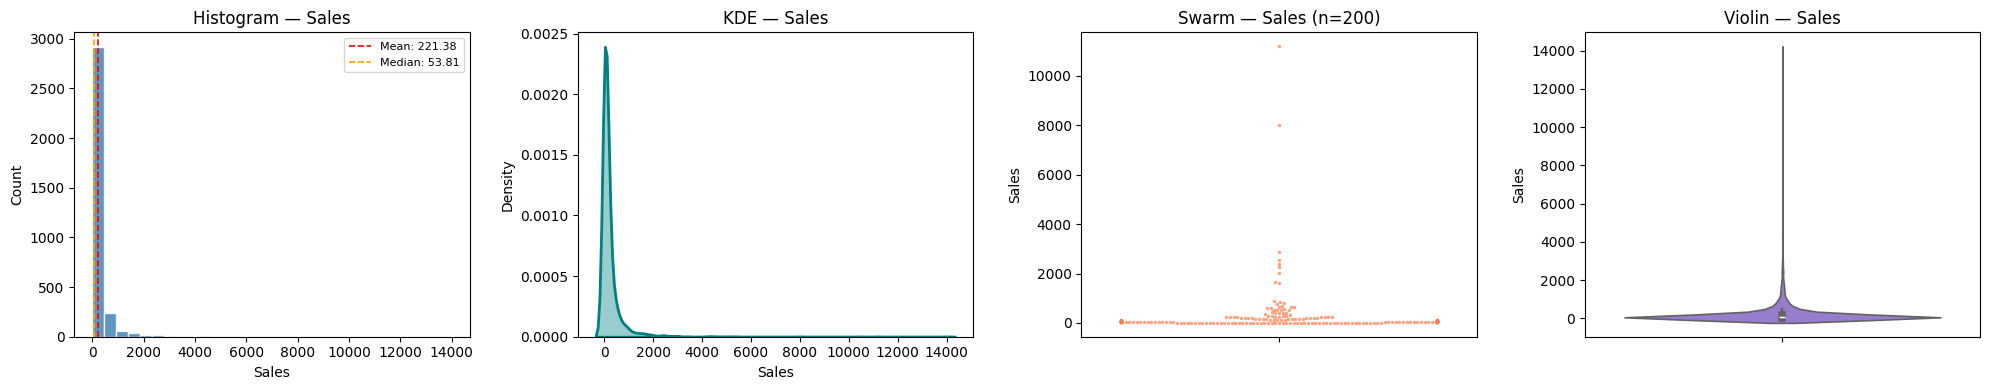

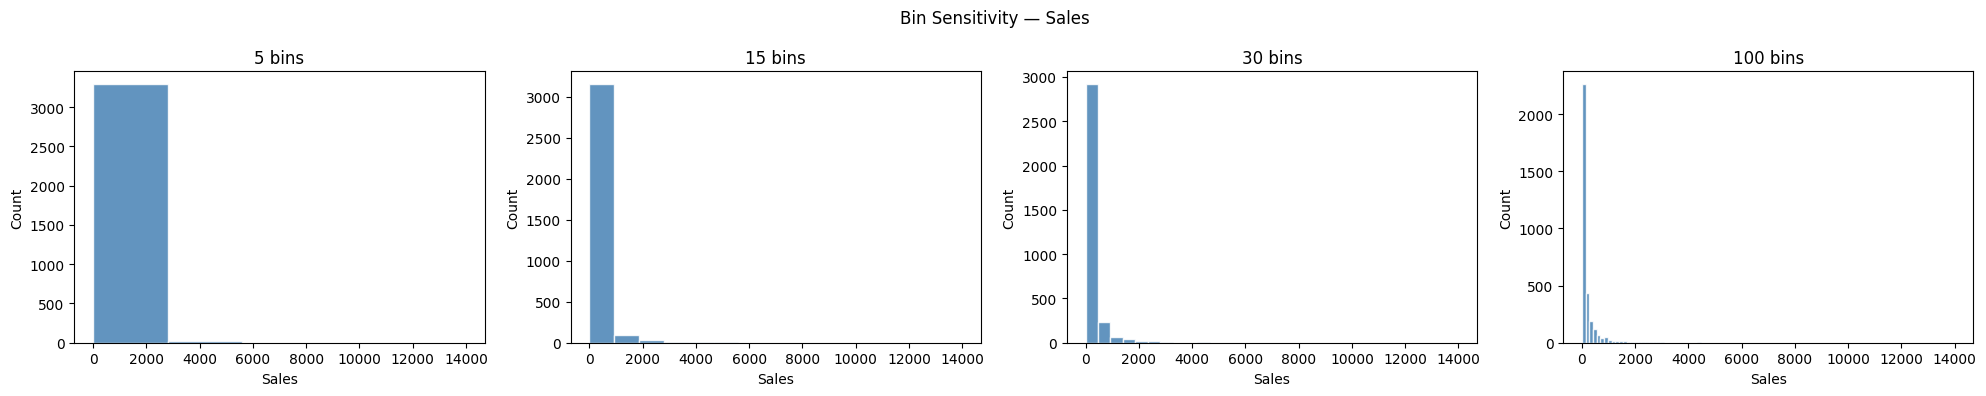

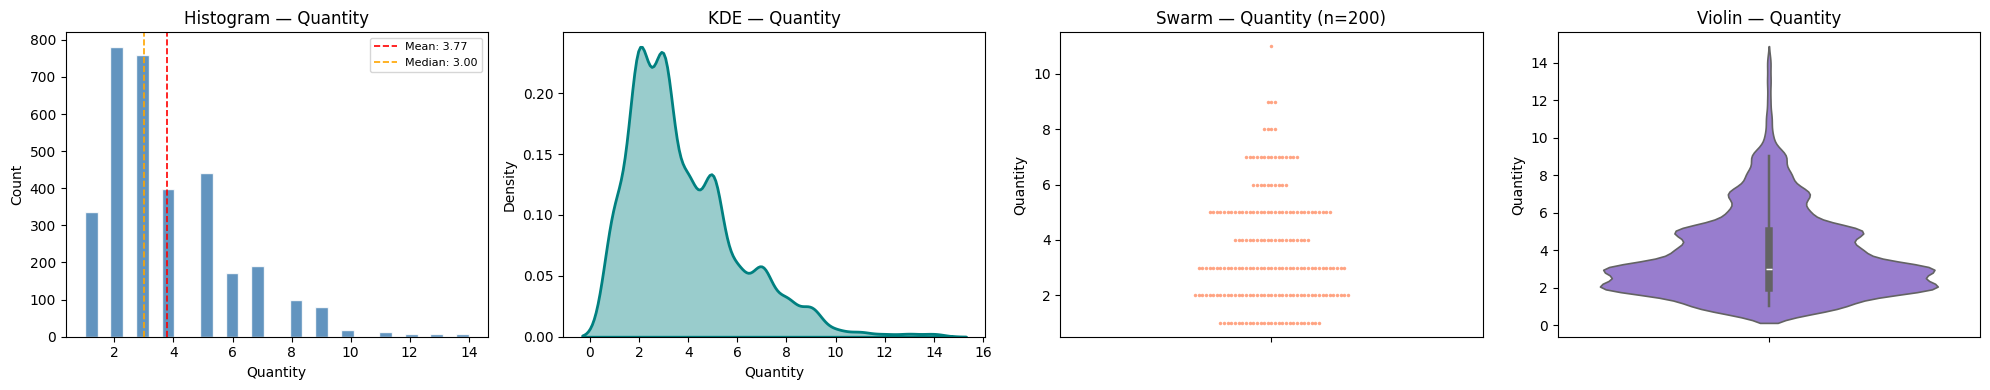

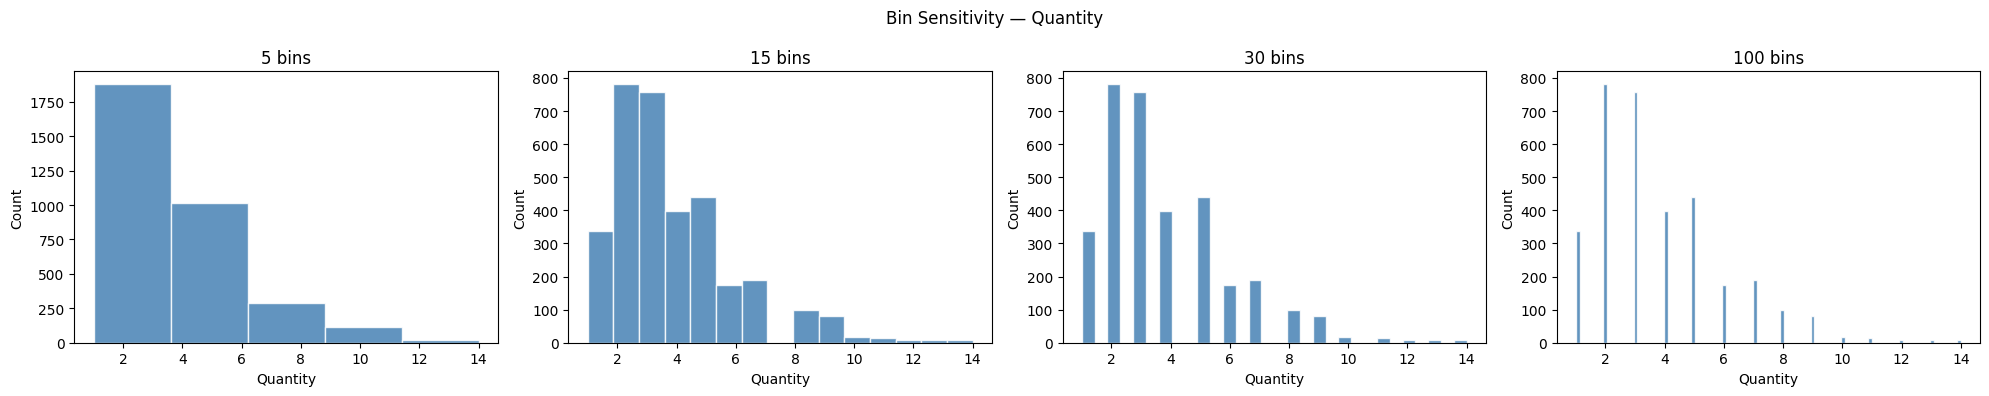

/Users/es864k/School/BU/venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


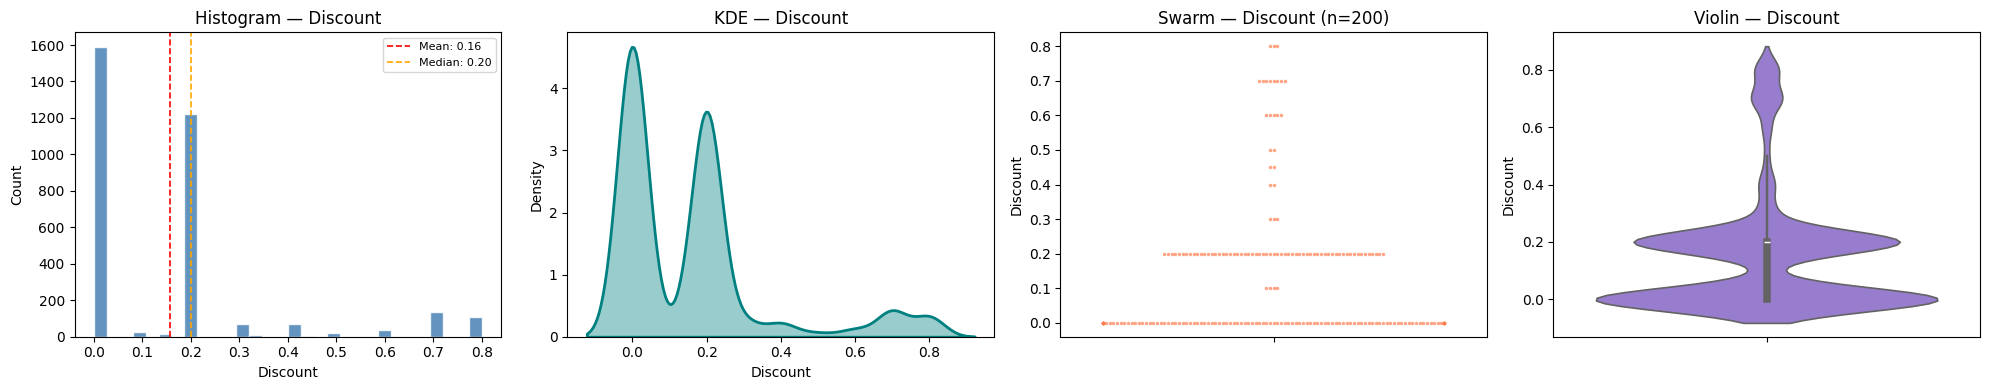

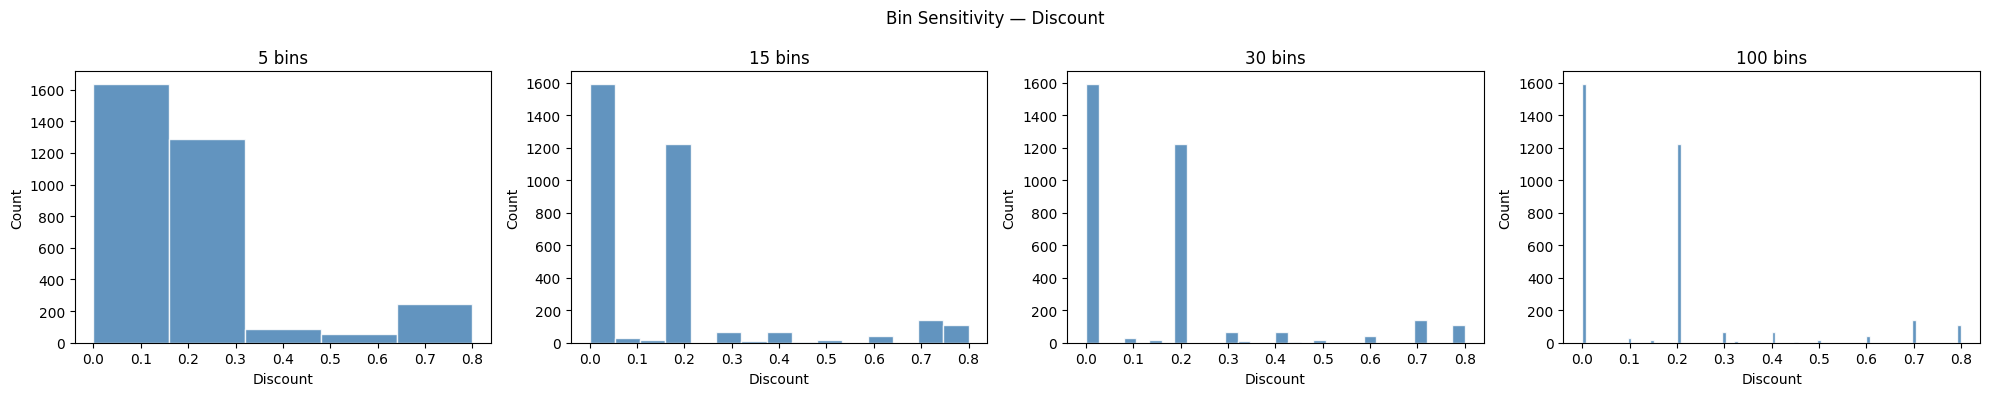

/Users/es864k/School/BU/venv/lib/python3.14/site-packages/seaborn/categorical.py:3399: UserWarning: 34.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


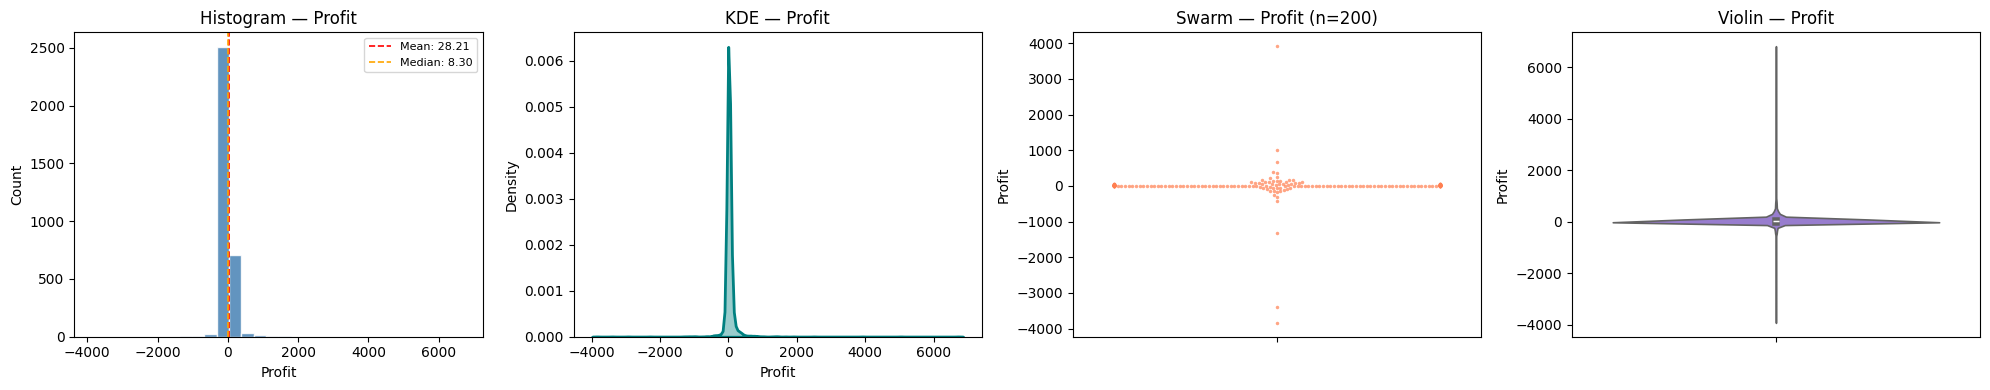

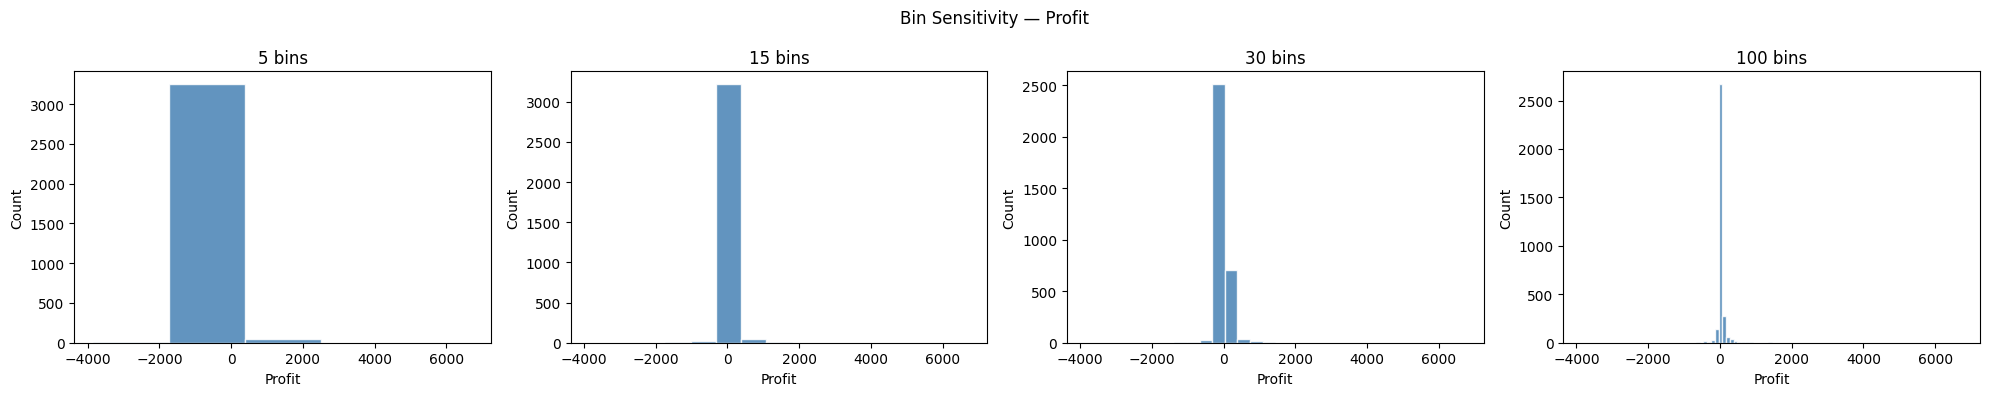


--- Categorical Features ---


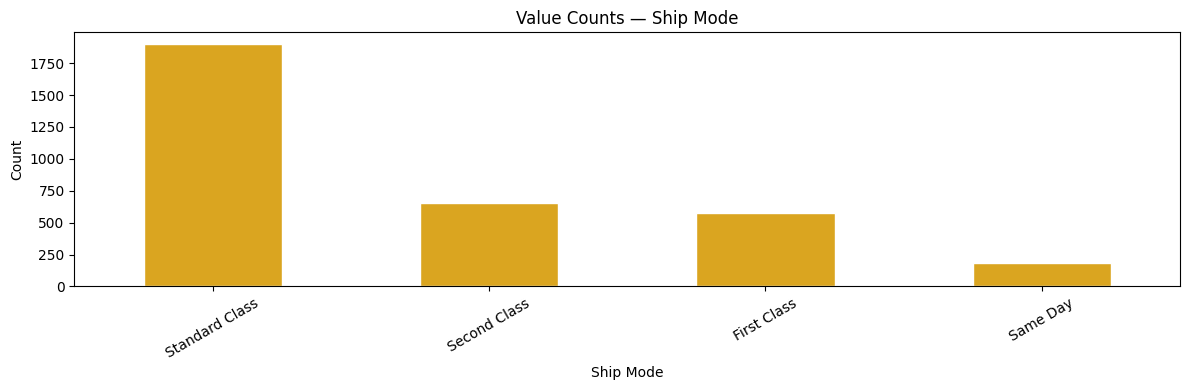

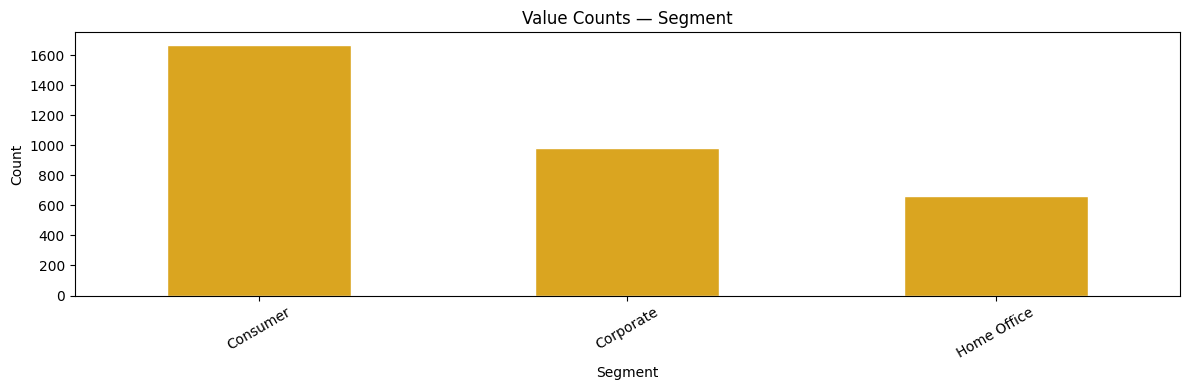

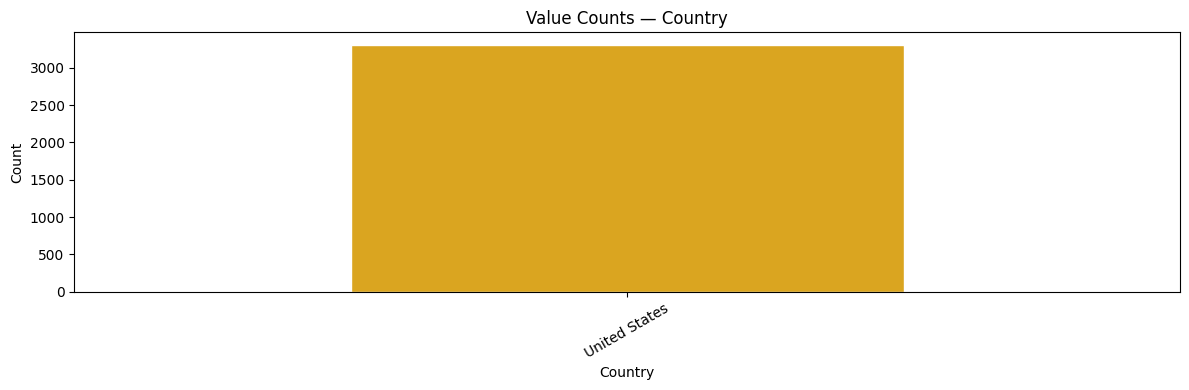

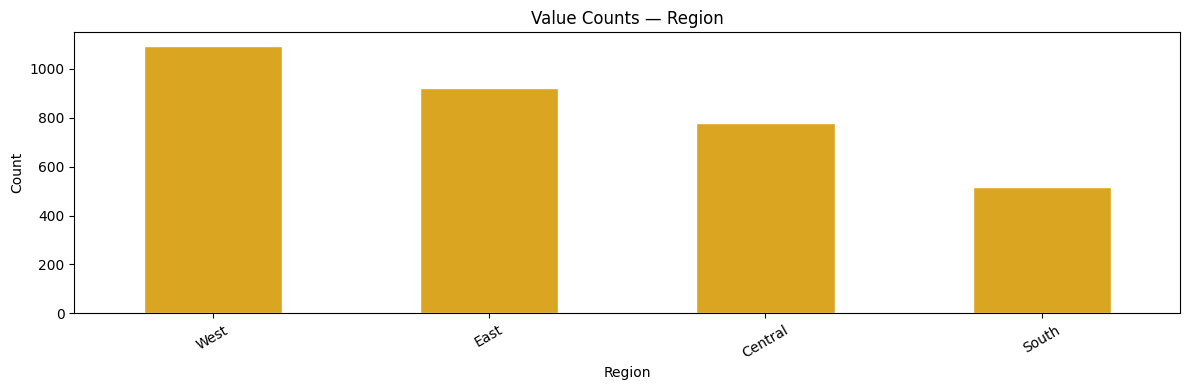

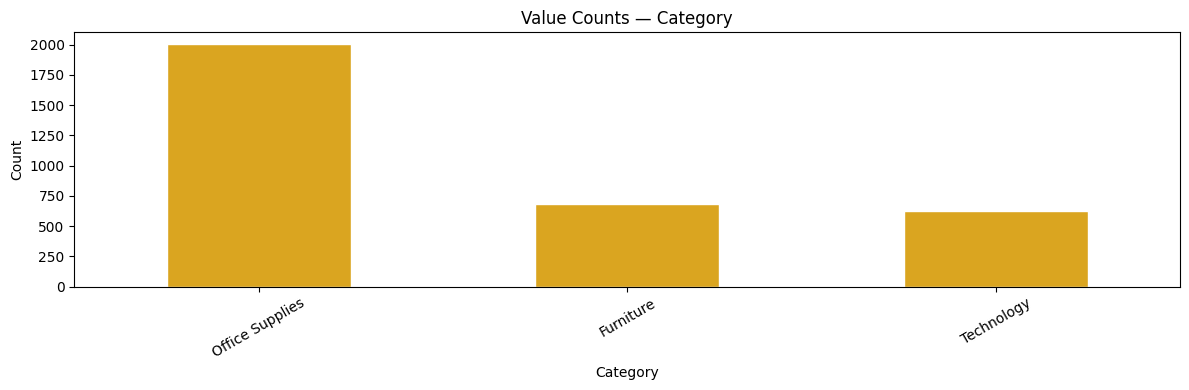

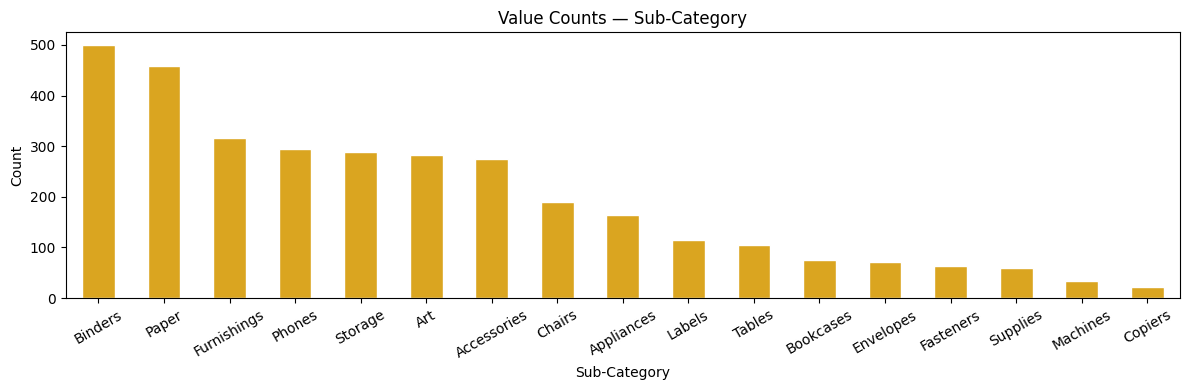


--- Grouped Features ---


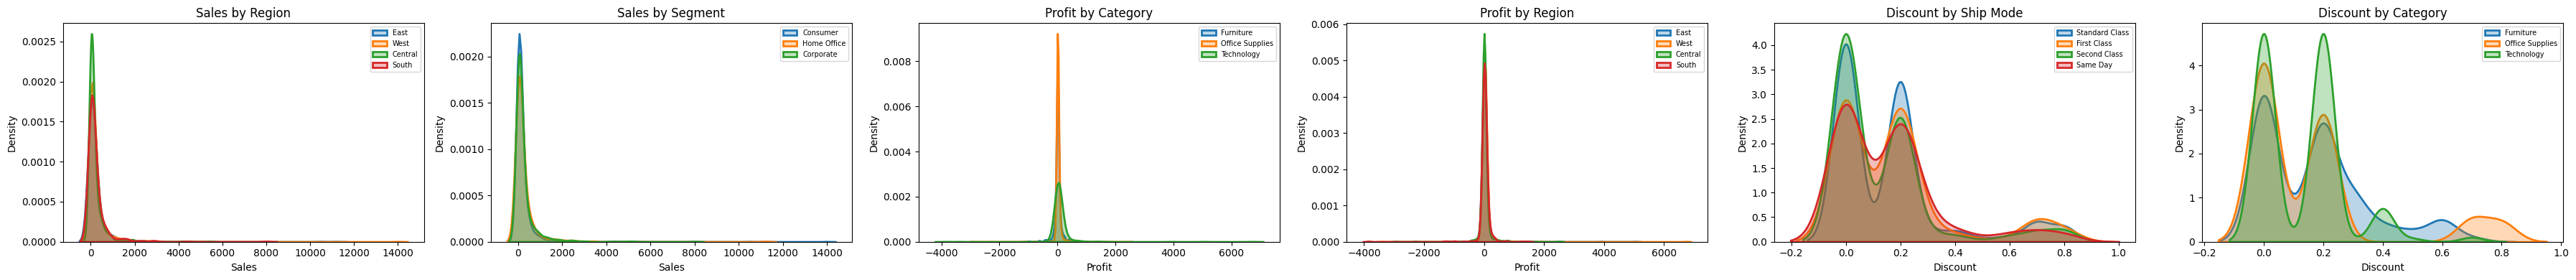

In [12]:
groupings = [
    ('Sales', 'Region'),
    ('Sales', 'Segment'),
    ('Profit', 'Category'),
    ('Profit', 'Region'),
    ('Discount', 'Ship Mode'),
    ('Discount', 'Category'),
]

analyze_dataset(df, groupings, dataset_name='US E-Commerce Records')

## Bivariate Analysis

In [13]:
## Bivariate helpers
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_pairplot(df, numeric_cols, hue_col=None, sample_n=1000):
    data = df[numeric_cols + ([hue_col] if hue_col else [])].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    g = sns.pairplot(data, hue=hue_col, plot_kws={'alpha': 0.3, 's': 15},
                     diag_kind='kde', palette='tab10')
    g.fig.suptitle('Pairplot' + (f' by {hue_col}' if hue_col else ''), y=1.02)
    plt.show()


def plot_line_by_time(df, time_col, numeric_col, ax, groupby_col=None, agg='mean'):
    if groupby_col:
        for group, gdf in df.groupby(groupby_col):
            agg_data = gdf.groupby(time_col)[numeric_col].agg(agg).sort_index()
            ax.plot(agg_data.index, agg_data.values, label=str(group), alpha=0.8)
        ax.legend(fontsize=7, title=groupby_col)
    else:
        agg_data = df.groupby(time_col)[numeric_col].agg(agg).sort_index()
        ax.fill_between(agg_data.index, agg_data.values, alpha=0.3, color='steelblue')
        ax.plot(agg_data.index, agg_data.values, color='steelblue', linewidth=2)
    ax.set_title(f'{agg.capitalize()} {numeric_col} by {time_col}')
    ax.set_xlabel(time_col)
    ax.set_ylabel(f'{agg} {numeric_col}')


def plot_correlation_heatmap(df, numeric_cols, ax):
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
    ax.set_title('Correlation Matrix')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


def plot_boxplot_by_category(df, numeric_col, cat_col, ax, top_n=10):
    top_cats = df[cat_col].value_counts().head(top_n).index
    data = df[df[cat_col].isin(top_cats)]
    sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,
                palette='Set2', order=top_cats)
    ax.set_title(f'{numeric_col} by {cat_col} (top {top_n})')
    ax.tick_params(axis='x', rotation=40)


def plot_grouped_bar(df, cat_col, numeric_col, ax, top_n=10, agg='mean'):
    grouped = df.groupby(cat_col)[numeric_col].agg(agg).sort_values(ascending=False).head(top_n)
    grouped.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{agg.capitalize()} {numeric_col} by {cat_col} (top {top_n})')
    ax.set_xlabel(cat_col)
    ax.set_ylabel(f'{agg} {numeric_col}')
    ax.tick_params(axis='x', rotation=40)


def plot_heatmap_two_categoricals(df, col_x, col_y, ax, top_n=10):
    top_x = df[col_x].value_counts().head(top_n).index
    top_y = df[col_y].value_counts().head(top_n).index
    pivot = df[df[col_x].isin(top_x) & df[col_y].isin(top_y)]\
              .groupby([col_y, col_x]).size().unstack(fill_value=0)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Count Heatmap: {col_y} vs {col_x}')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)


def plot_scatter(df, col_x, col_y, ax, sample_n=2000, hue_col=None):
    data = df[[col_x, col_y] + ([hue_col] if hue_col else [])].dropna()
    if len(data) > sample_n:
        data = data.sample(sample_n, random_state=42)
    sns.scatterplot(data=data, x=col_x, y=col_y, ax=ax,
                    hue=hue_col, alpha=0.4, s=20,
                    palette='tab10' if hue_col else None)
    ax.set_title(f'{col_x} vs {col_y}' + (f' (by {hue_col})' if hue_col else ''))


def analyze_dataset_bi_variate(
    df,
    numeric_cols,            # list of numeric cols for correlation heatmap
    boxplot_pairs,           # list of (numeric_col, cat_col)
    grouped_bar_pairs,       # list of (cat_col, numeric_col, agg) — agg: 'mean' | 'sum' | 'median'
    heatmap_pairs,           # list of (col_x, col_y) — two categoricals
    scatter_pairs,           # list of (col_x, col_y) or (col_x, col_y, hue_col)
    pairplot_cols=None,      # (numeric_cols_list, optional hue_col)
    line_pairs=None,          # list of (time_col, numeric_col, agg) or (time_col, numeric_col, agg, groupby_col)
    dataset_name='Dataset'
):
    print(f"{'='*100}")
    print(f"  {dataset_name} — Bivariate Analysis")
    print(f"{'='*100}")

    # Correlation heatmap
    if numeric_cols:
        print("\n--- Correlation Matrix ---")
        fig, ax = plt.subplots(figsize=(10, 8))
        plot_correlation_heatmap(df, numeric_cols, ax)
        plt.tight_layout()
        plt.show()

    # Boxplots
    if boxplot_pairs:
        print("\n--- Boxplots ---")
        for numeric_col, cat_col in boxplot_pairs:
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_boxplot_by_category(df, numeric_col, cat_col, ax)
            plt.tight_layout()
            plt.show()

    # Grouped bar charts
    if grouped_bar_pairs:
        print("\n--- Grouped Bar Charts ---")
        for cat_col, numeric_col, agg in grouped_bar_pairs:
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_grouped_bar(df, cat_col, numeric_col, ax, agg=agg)
            plt.tight_layout()
            plt.show()

    # Two-categorical heatmaps
    if heatmap_pairs:
        print("\n--- Category Heatmaps ---")
        for col_x, col_y in heatmap_pairs:
            fig, ax = plt.subplots(figsize=(12, 6))
            plot_heatmap_two_categoricals(df, col_x, col_y, ax)
            plt.tight_layout()
            plt.show()

    # Scatter plots
    if scatter_pairs:
        print("\n--- Scatter Plots ---")
        for pair in scatter_pairs:
            col_x, col_y = pair[0], pair[1]
            hue_col = pair[2] if len(pair) == 3 else None
            fig, ax = plt.subplots(figsize=(10, 6))
            plot_scatter(df, col_x, col_y, ax, hue_col=hue_col)
            plt.tight_layout()
            plt.show()
    # Pairplot
    if pairplot_cols:
        print("\n--- Pairplot ---")
        cols, hue_col = pairplot_cols[0], pairplot_cols[1] if len(pairplot_cols) > 1 else None
        plot_pairplot(df, cols, hue_col=hue_col)

    # Line / area graphs
    if line_pairs:
        print("\n--- Line / Area Graphs ---")
        for pair in line_pairs:
            time_col, numeric_col, agg = pair[0], pair[1], pair[2]
            groupby_col = pair[3] if len(pair) == 4 else None
            fig, ax = plt.subplots(figsize=(12, 5))
            plot_line_by_time(df, time_col, numeric_col, ax, groupby_col=groupby_col, agg=agg)
            plt.tight_layout()
            plt.show()

  US E-Commerce Records — Bivariate Analysis

--- Correlation Matrix ---


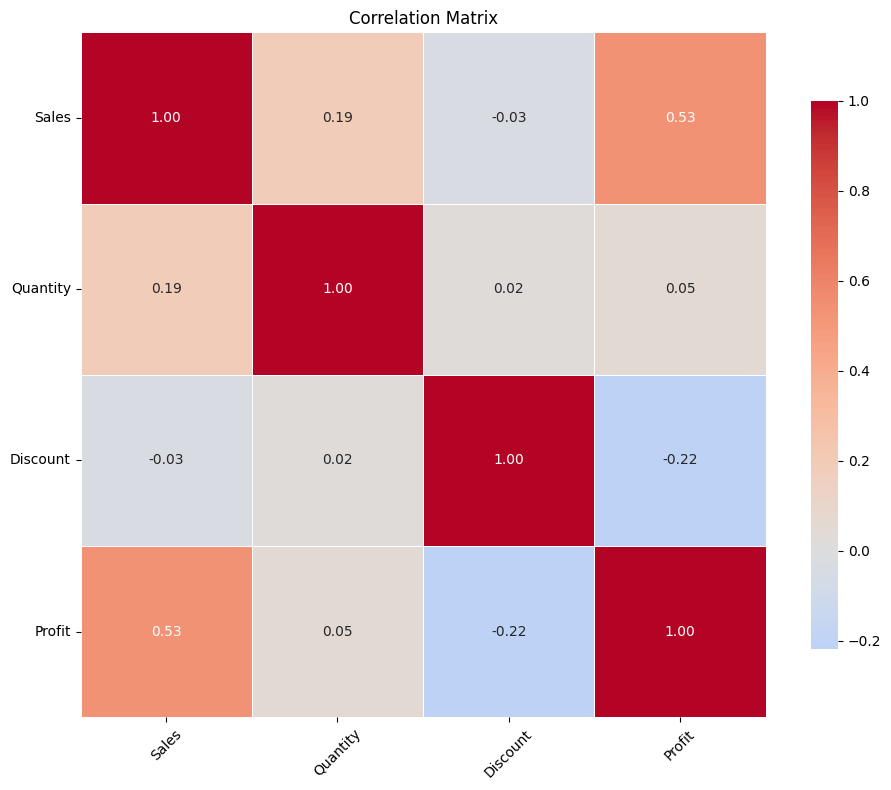


--- Boxplots ---


/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_93030/1659448462.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,


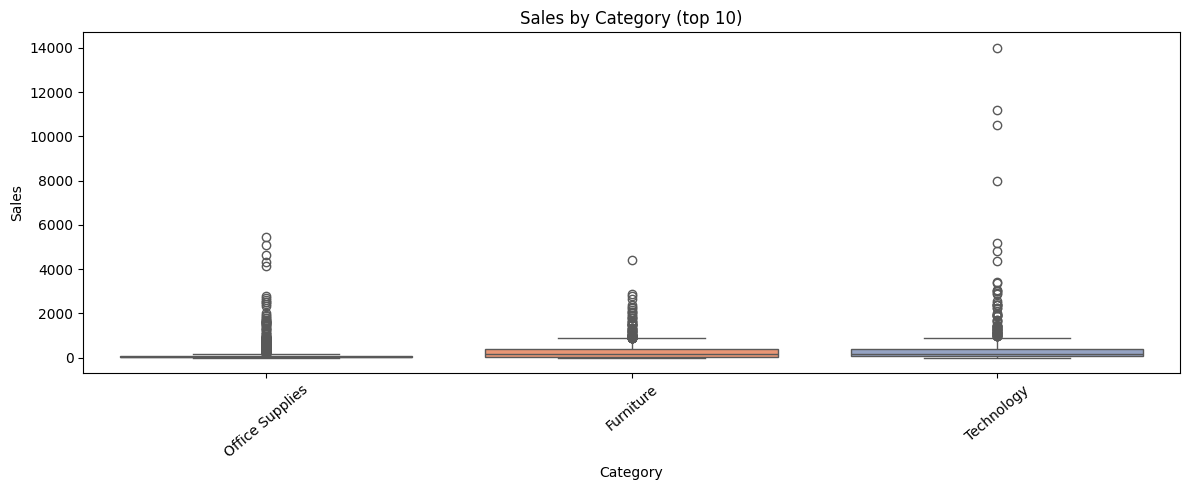

/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_93030/1659448462.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,


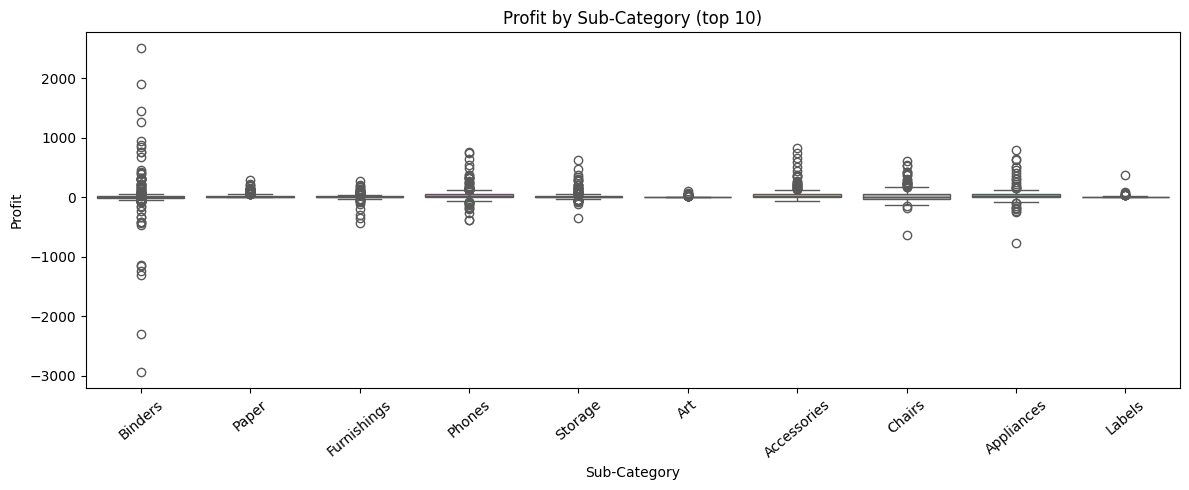

/var/folders/xp/db574fvx2lq4165qj0ww45r40000gp/T/ipykernel_93030/1659448462.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=cat_col, y=numeric_col, ax=ax,


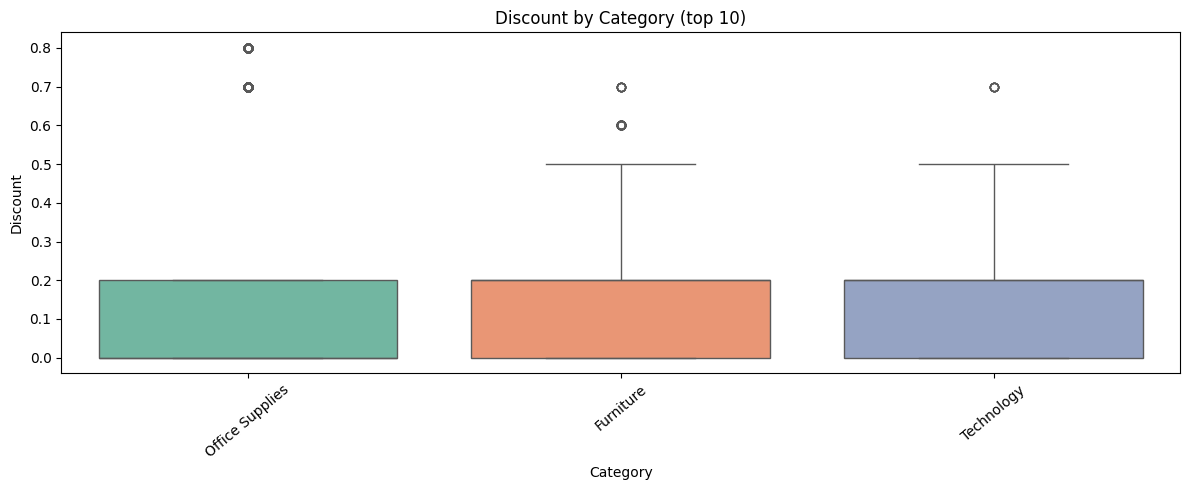


--- Grouped Bar Charts ---


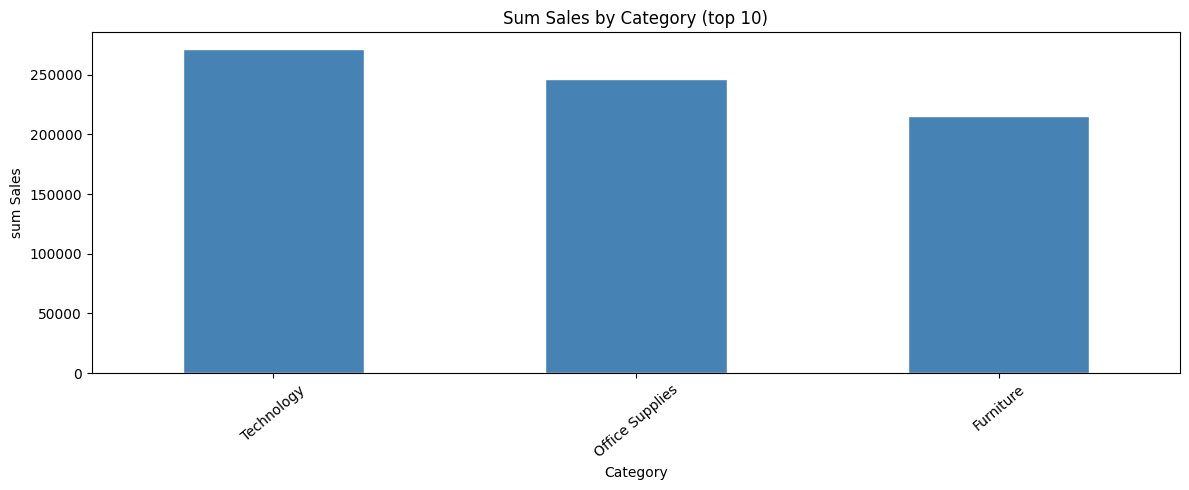

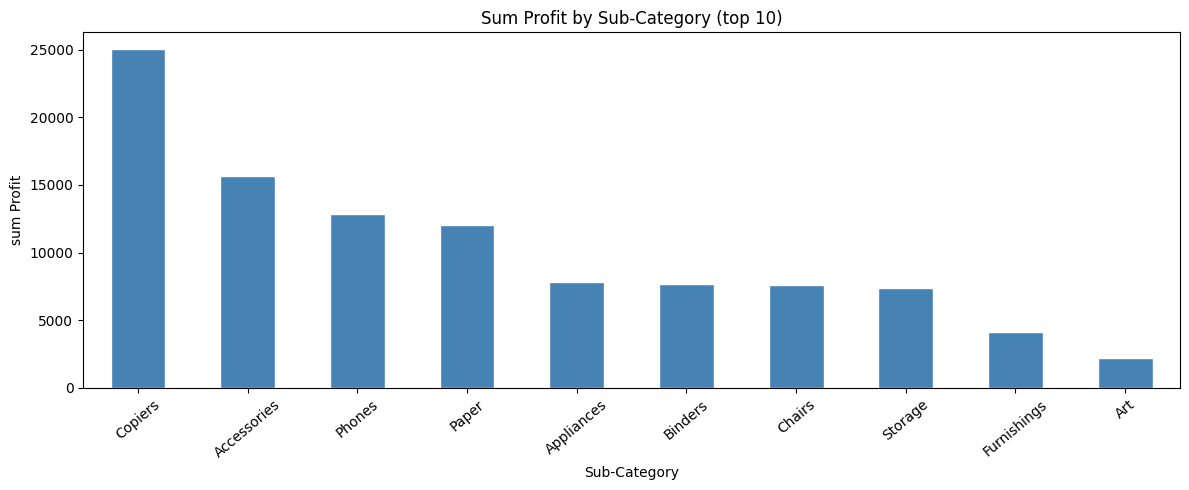

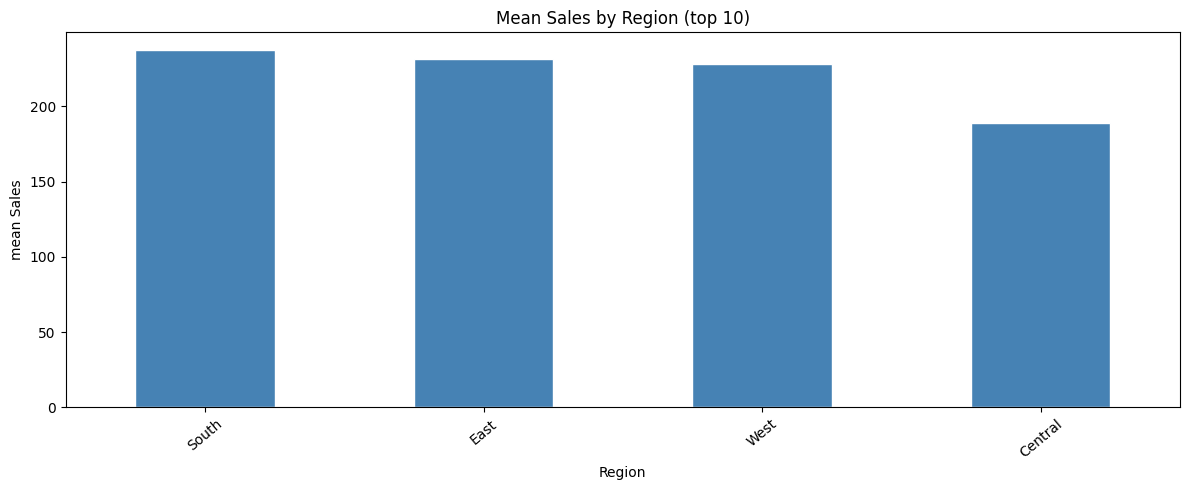

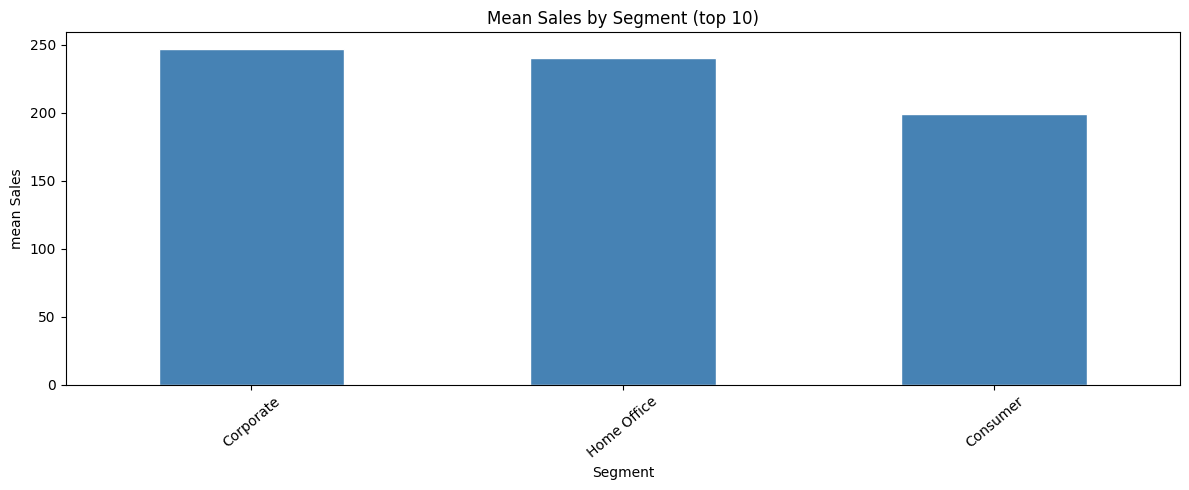


--- Category Heatmaps ---


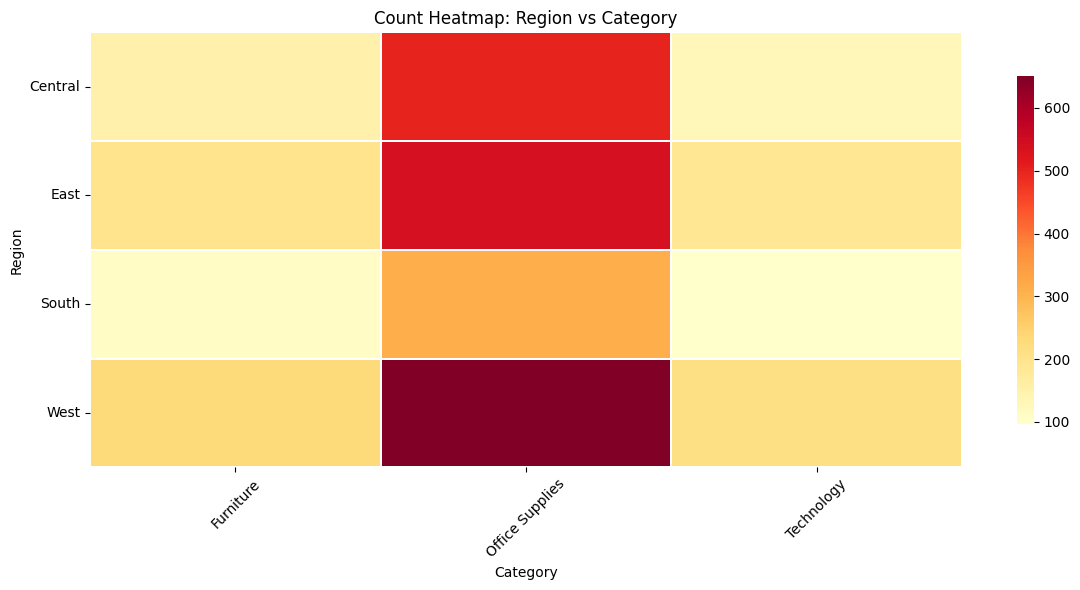

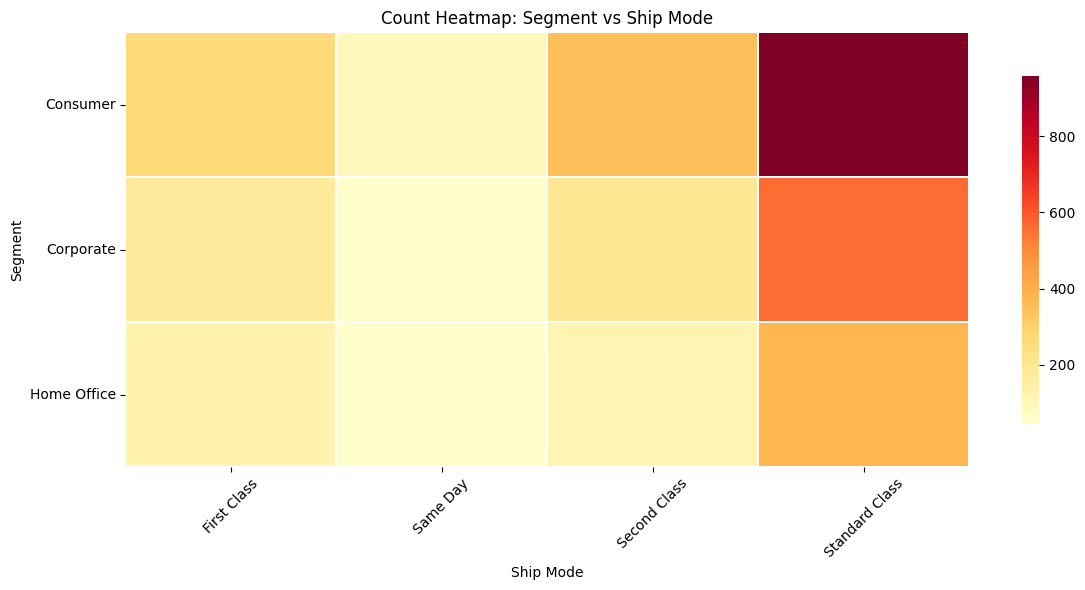


--- Scatter Plots ---


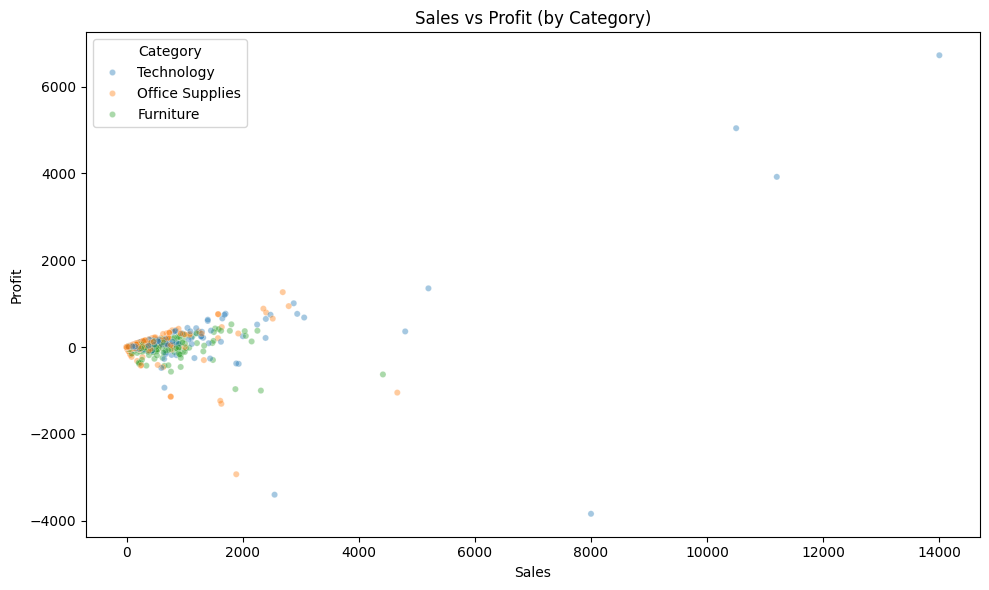

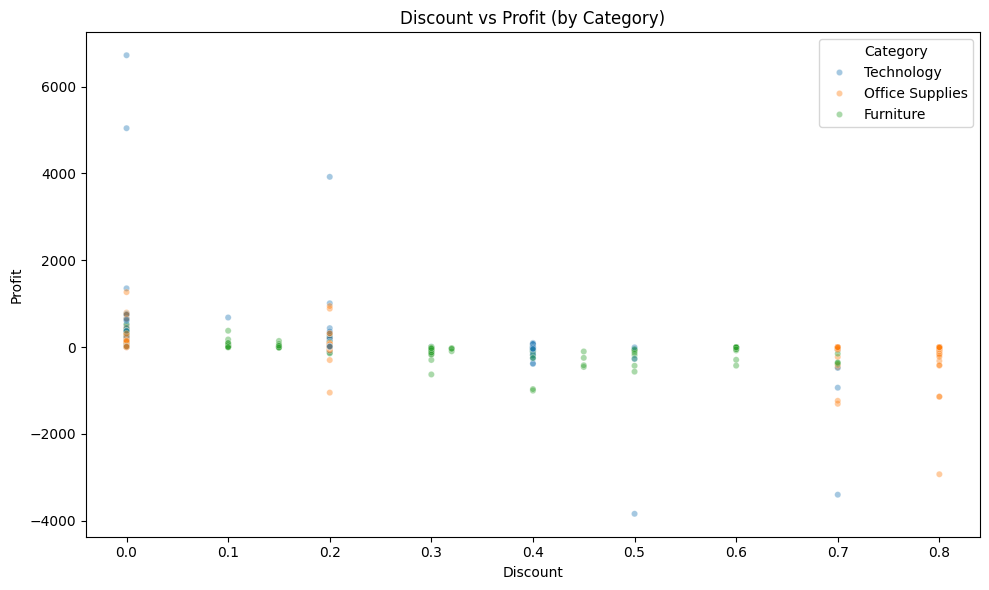


--- Pairplot ---


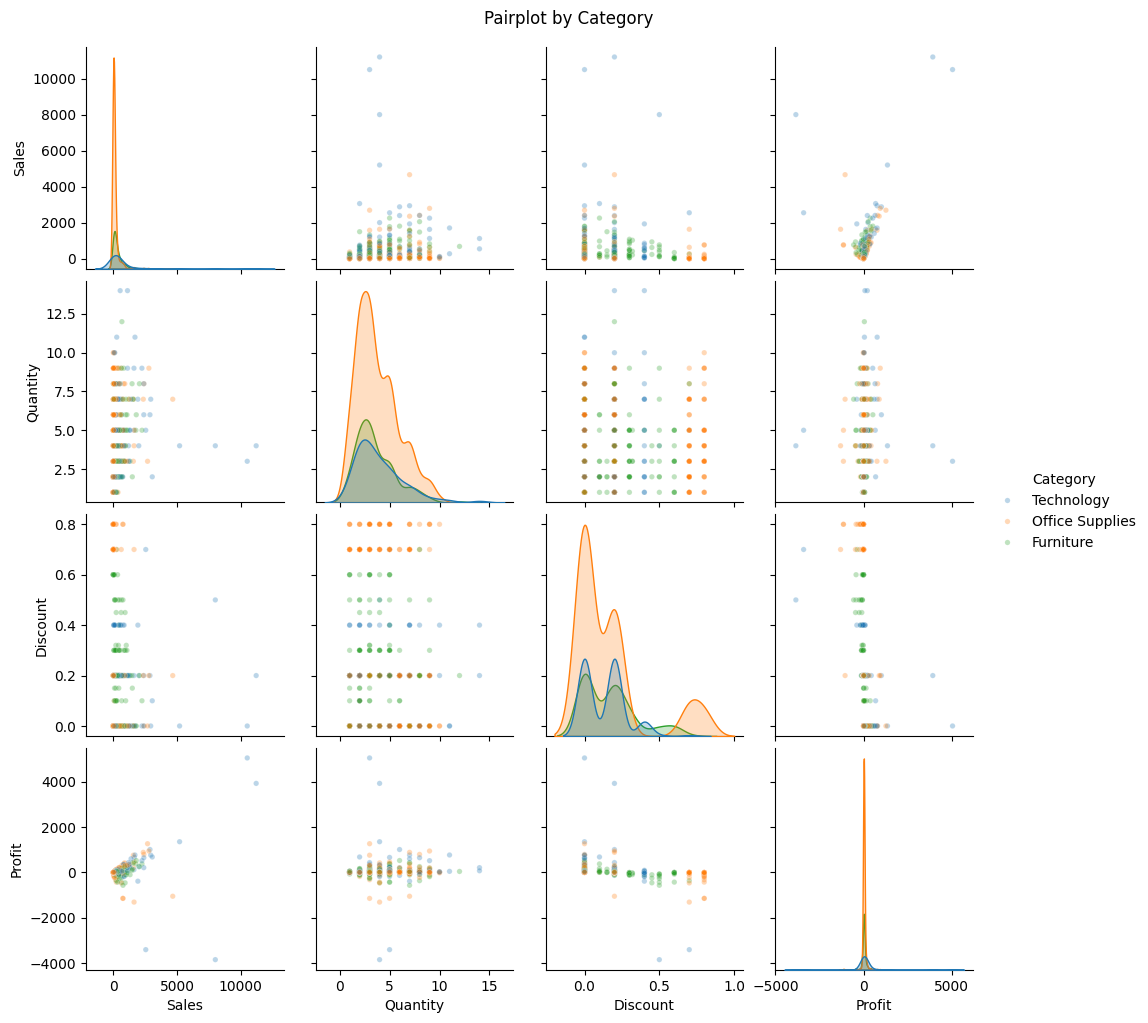


--- Line / Area Graphs ---


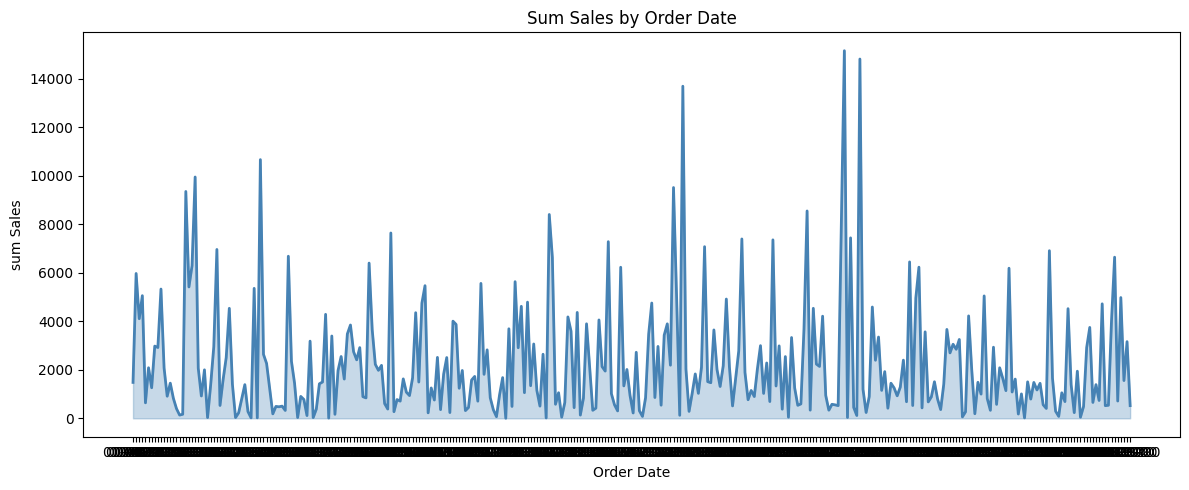

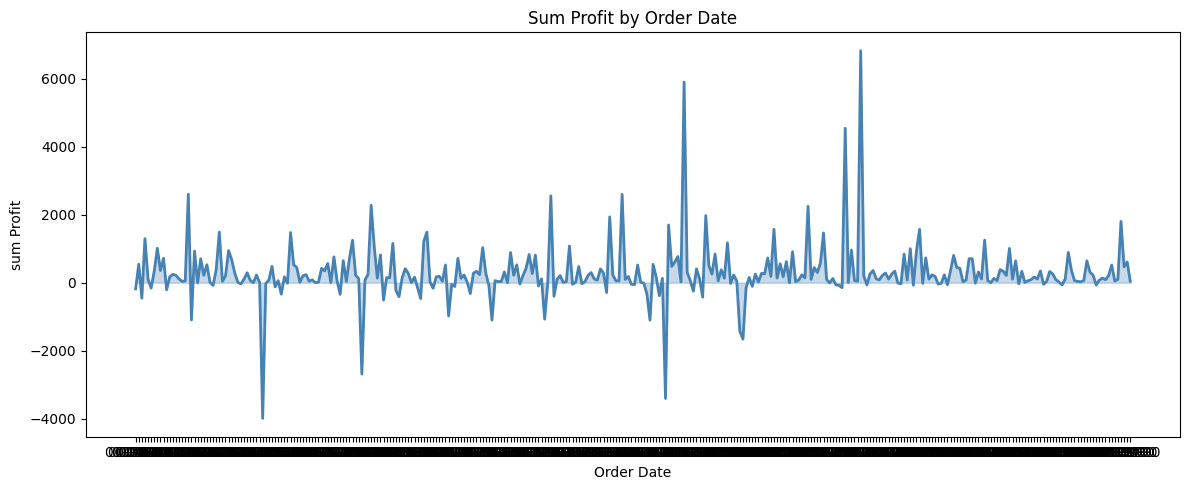

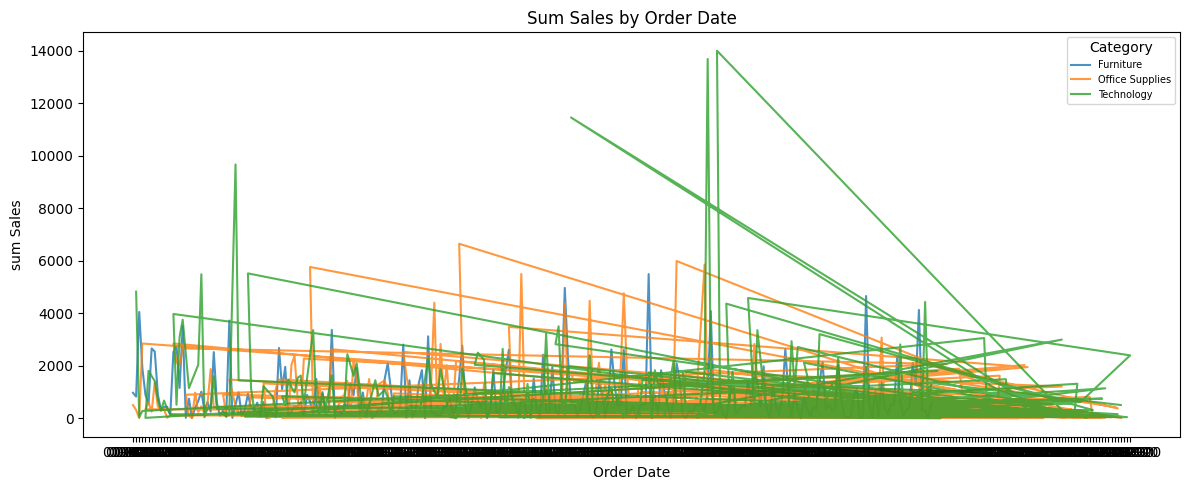

In [14]:
# US E-Commerce bivariate analysis
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

# (numeric_col, cat_col)
boxplot_pairs = [
    ('Sales', 'Category'),
    ('Profit', 'Sub-Category'),
    ('Discount', 'Category'),
]

# (cat_col, numeric_col, agg)
grouped_bar_pairs = [
    ('Category', 'Sales', 'sum'),
    ('Sub-Category', 'Profit', 'sum'),
    ('Region', 'Sales', 'mean'),
    ('Segment', 'Sales', 'mean'),
]

# (col_x, col_y) — two categoricals
heatmap_pairs = [
    ('Category', 'Region'),
    ('Ship Mode', 'Segment'),
]

# (col_x, col_y) or (col_x, col_y, hue_col)
scatter_pairs = [
    ('Sales', 'Profit', 'Category'),
    ('Discount', 'Profit', 'Category'),
]

pairplot_cols = (
    ['Sales', 'Quantity', 'Discount', 'Profit'],
    'Category'
)

line_pairs = [
    ('Order Date', 'Sales', 'sum'),
    ('Order Date', 'Profit', 'sum'),
    ('Order Date', 'Sales', 'sum', 'Category'),
]

analyze_dataset_bi_variate(
    df,
    numeric_cols=numeric_cols,
    boxplot_pairs=boxplot_pairs,
    grouped_bar_pairs=grouped_bar_pairs,
    heatmap_pairs=heatmap_pairs,
    scatter_pairs=scatter_pairs,
    pairplot_cols=pairplot_cols,
    line_pairs=line_pairs,
    dataset_name='US E-Commerce Records'
)

## Figures Export

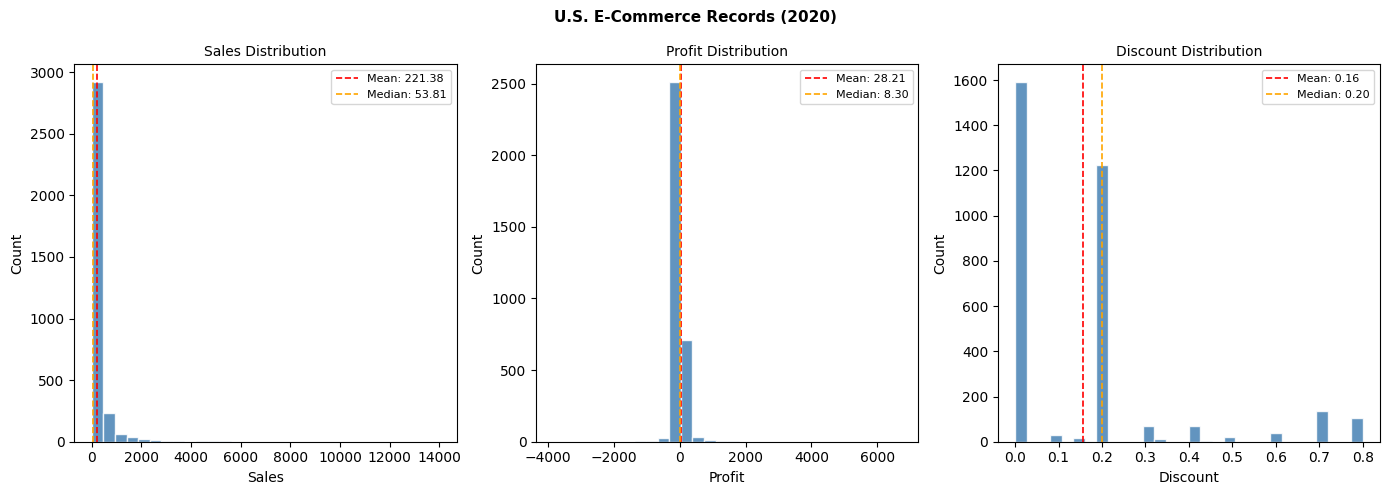

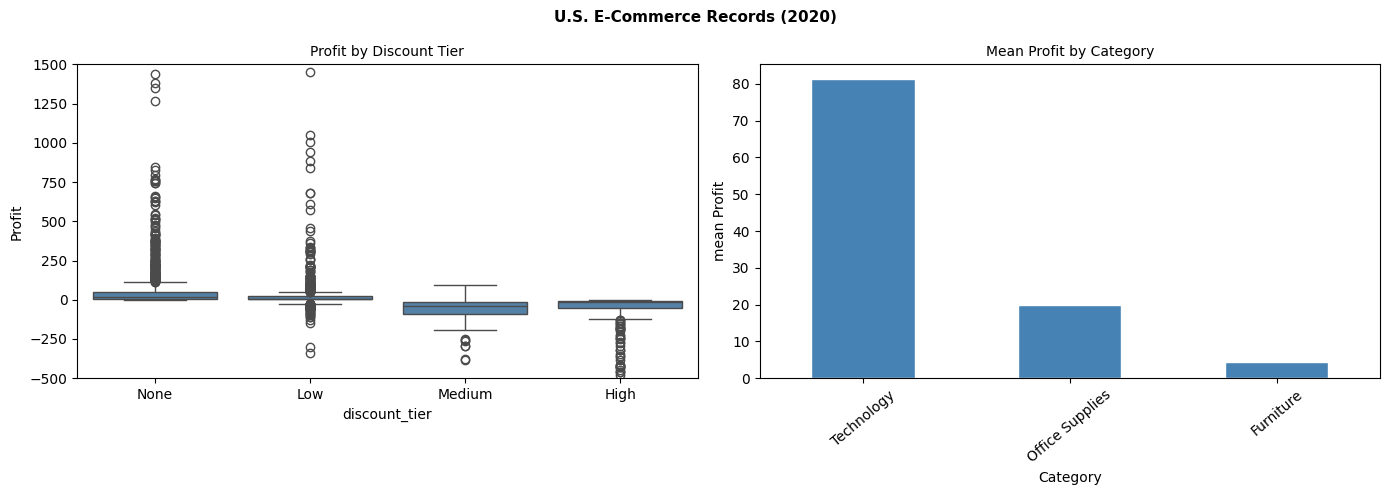

Figures saved to ./figures/


In [33]:
import os
os.makedirs('figures', exist_ok=True)

df['Order Date'] = pd.to_datetime(df['Order Date'])

# ── Dataset label (change this per notebook) ──────────────────────
DATASET_TITLE = "U.S. E-Commerce Records (2020)"
# ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(DATASET_TITLE, fontsize=11, fontweight='bold')

plot_histogram(df, 'Sales', axes[0])
axes[0].set_title('Sales Distribution', fontsize=10)

plot_histogram(df, 'Profit', axes[1])
axes[1].set_title('Profit Distribution', fontsize=10)

plot_histogram(df, 'Discount', axes[2])
axes[2].set_title('Discount Distribution', fontsize=10)

plt.tight_layout()
plt.savefig('figures/fig2_ecommerce_univariate.png', dpi=150)
plt.show()

# os.makedirs('figures', exist_ok=True)
# fig_size = (6, 5)

# # Fig 1 — Sales by Category
# fig, ax = plt.subplots(figsize=fig_size)
# plot_grouped_bar(df, 'Category', 'Sales', ax, agg='sum')
# ax.set_title('Figure 1 — Total Sales by Category')
# plt.tight_layout()
# plt.savefig('figures/fig1_sales_by_category.png', dpi=150)
# plt.show()

# # Fig 2 — Profit by Sub-Category
# fig, ax = plt.subplots(figsize=fig_size)
# plot_grouped_bar(df, 'Sub-Category', 'Profit', ax, agg='sum', top_n=10)
# ax.set_title('Figure 2 — Total Profit by Sub-Category')
# plt.tight_layout()
# plt.savefig('figures/fig2_profit_by_subcategory.png', dpi=150)
# plt.show()

# # Fig 3 — Sales vs Profit scatter
# fig, ax = plt.subplots(figsize=fig_size)
# plot_scatter(df, 'Sales', 'Profit', ax, hue_col='Category')
# ax.set_title('Figure 3 — Sales vs Profit by Category')
# plt.tight_layout()
# plt.savefig('figures/fig3_sales_vs_profit.png', dpi=150)
# plt.show()

# # Fig 4 — Discount vs Profit scatter
# fig, ax = plt.subplots(figsize=fig_size)
# plot_scatter(df, 'Discount', 'Profit', ax, hue_col='Category')
# ax.set_title('Figure 4 — Discount vs Profit by Category')
# plt.tight_layout()
# plt.savefig('figures/fig4_discount_vs_profit.png', dpi=150)
# plt.show()

# # Fig 5 — Sales over time
# fig, ax = plt.subplots(figsize=fig_size)
# plot_line_by_time(df, 'Order Date', 'Sales', ax, agg='sum')
# ax.set_title('Figure 5 — Sales Over Time')
# plt.tight_layout()
# plt.savefig('figures/fig5_sales_over_time.png', dpi=150)
# plt.show()

# # Fig 6 — Category x Region heatmap
# fig, ax = plt.subplots(figsize=fig_size)
# plot_heatmap_two_categoricals(df, 'Category', 'Region', ax)
# ax.set_title('Figure 6 — Orders by Category and Region')
# plt.tight_layout()
# plt.savefig('figures/fig6_category_region_heatmap.png', dpi=150)
# plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(DATASET_TITLE, fontsize=11, fontweight='bold')

# Left — Profit by Discount Tier
df['discount_tier'] = pd.cut(df['Discount'],
    bins=[-0.01, 0, 0.2, 0.4, 1.0],
    labels=['None', 'Low', 'Medium', 'High'])
sns.boxplot(data=df, x='discount_tier', y='Profit', ax=axes[0], color='steelblue')
axes[0].set_title('Profit by Discount Tier', fontsize=10)
axes[0].set_ylim(-500, 1500)

# Right — Mean Profit by Category
plot_grouped_bar(df, 'Category', 'Profit', axes[1], agg='mean')
axes[1].set_title('Mean Profit by Category', fontsize=10)

plt.tight_layout()
plt.savefig('figures/fig5_ecommerce_bivariate.png', dpi=150)
plt.show()

print("Figures saved to ./figures/")